In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import os
import pygtc

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
fid50 = jsm_ancillary.load_massspec("../../data/Nparticle/N50/", "artificial", 0)

satgen50 = fid50[fid50["logMvir"] > 12.5]
satgen50 = satgen50.sort_values("logMvir")

In [5]:
fid500 = jsm_ancillary.load_massspec("../../data/Nparticle/N500/", "artificial", 0)

satgen500 = fid500[fid500["logMvir"] > 12.5]
satgen500 = satgen500.sort_values("logMvir")

In [6]:
fid1000 = jsm_ancillary.load_massspec("../../data/Nparticle/N1000/", "artificial", 0)

satgen1000 = fid1000[fid1000["logMvir"] > 12.5]
satgen1000 = satgen1000.sort_values("logMvir")

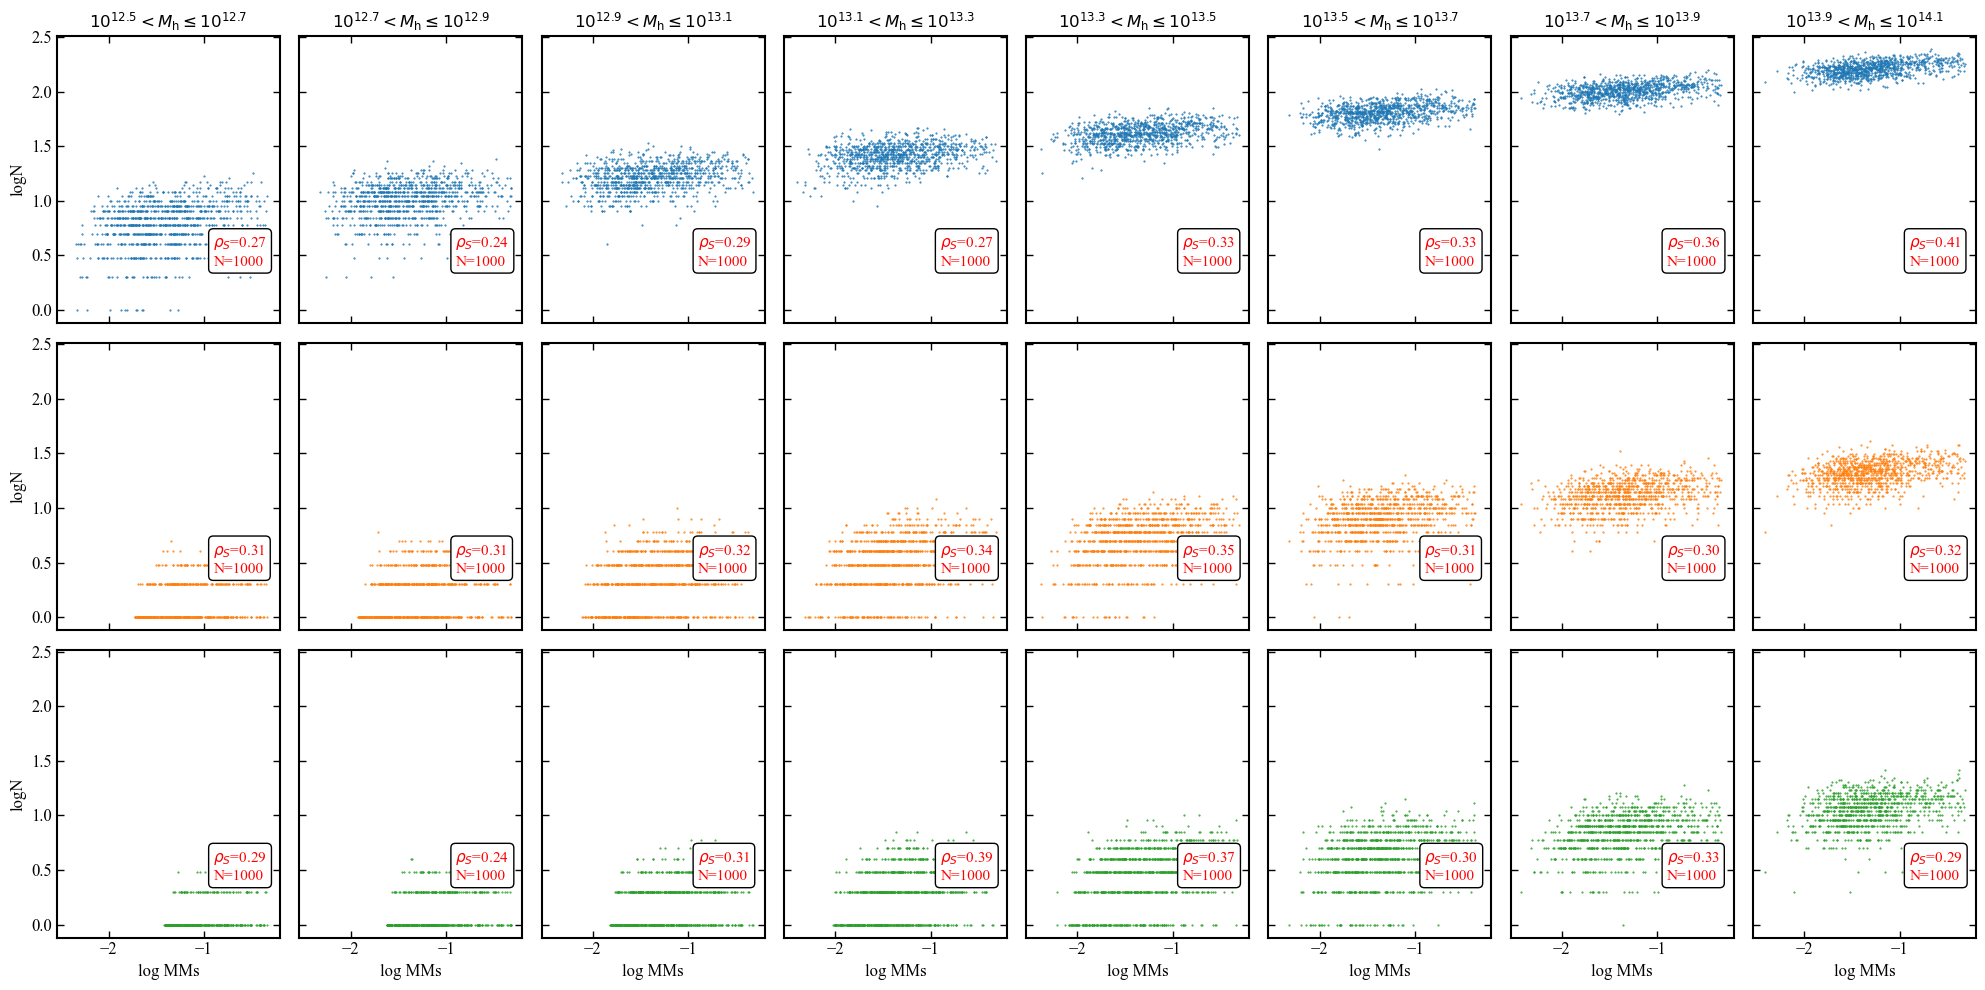

In [7]:
rho_matz, rho_err_matz, N_hosts = jsm_simload.mass_binned_correlation([satgen50, satgen500, satgen1000], xkey="log1pz50", ykey="logNsub", xlabel="log(1+z50)", ylabel="logN", make_plot=False)

rho_matc, rho_err_matc, _ = jsm_simload.mass_binned_correlation([satgen50, satgen500, satgen1000], xkey="logc", ykey="logNsub", xlabel="log c", ylabel="logN", make_plot=False)

rho_matm, rho_err_matm, _ = jsm_simload.mass_binned_correlation([satgen50, satgen500, satgen1000], xkey="logMMs", ykey="logNsub", xlabel="log MMs", ylabel="logN", make_plot=True)

In [9]:
logMvir_binned = np.linspace(12.6, 14, 8)

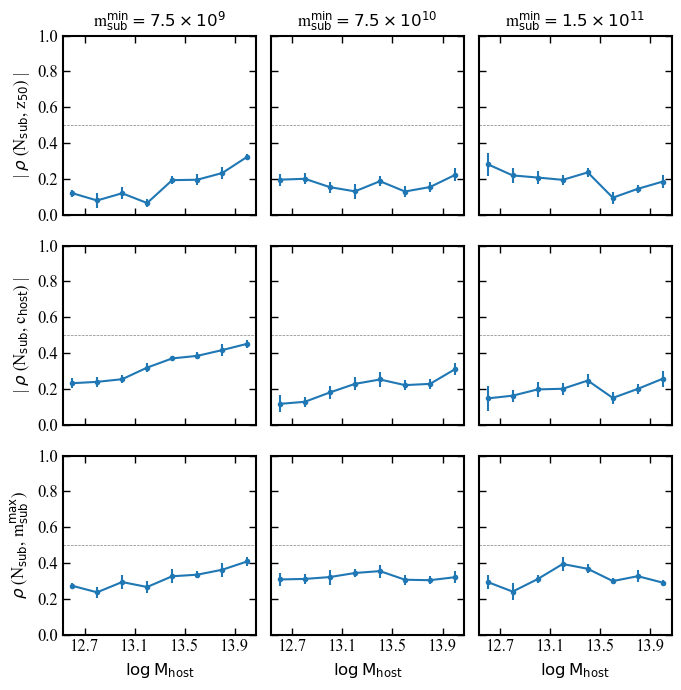

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(double_textwidth, double_textwidth), sharex=True, sharey=True)

axes[0,0].errorbar(logMvir_binned, np.abs(rho_matz[0]), yerr=rho_err_matz[0], marker=".")
axes[0,1].errorbar(logMvir_binned, np.abs(rho_matz[1]), yerr=rho_err_matz[1], marker=".")
axes[0,2].errorbar(logMvir_binned, np.abs(rho_matz[2]), yerr=rho_err_matz[2], marker=".")


axes[1,0].errorbar(logMvir_binned, np.abs(rho_matc[0]), yerr=rho_err_matc[0], marker=".")
axes[1,1].errorbar(logMvir_binned, np.abs(rho_matc[1]), yerr=rho_err_matc[1], marker=".")
axes[1,2].errorbar(logMvir_binned, np.abs(rho_matc[2]), yerr=rho_err_matc[2], marker=".")

axes[2,0].errorbar(logMvir_binned, np.abs(rho_matm[0]), yerr=rho_err_matm[0], marker=".")
axes[2,1].errorbar(logMvir_binned, np.abs(rho_matm[1]), yerr=rho_err_matm[1], marker=".")
axes[2,2].errorbar(logMvir_binned, np.abs(rho_matm[2]), yerr=rho_err_matm[2], marker=".")

axes[0, 0].set_ylim(0,1)
axes[0, 0].set_xticks([12.7, 13.1, 13.5, 13.9])

axes[0, 0].set_ylabel("| $\\rho$ (N$_{\\rm sub}$, z$_{50}$) |")
axes[1, 0].set_ylabel("| $\\rho$ (N$_{\\rm sub}$, c$_{\\rm host}$) |")
axes[2, 0].set_ylabel("$\\rho$ (N$_{\\rm sub}$, m$_{\\rm sub}^{\\rm max}$)")

axes[2, 0].set_xlabel("$\\log \\rm M_{host}$")
axes[2, 1].set_xlabel("$\\log \\rm M_{host}$")
axes[2, 2].set_xlabel("$\\log \\rm M_{host}$")

axes[0, 0].set_title("m$_{\\rm sub}^{\\rm min} = 7.5 \\times 10^{9}$")
axes[0, 1].set_title("m$_{\\rm sub}^{\\rm min} = 7.5 \\times 10^{10}$")
axes[0, 2].set_title("m$_{\\rm sub}^{\\rm min} = 1.5 \\times 10^{11}$")

for ax in axes.flat:
    ax.axhline(0.5, ls="--", lw=0.5, color="grey")

plt.tight_layout()

In [ ]:
# full_corr = np.array([rho_matz, rho_matc, rho_matm])
# np.save("../../data/Nparticle/satgen.npy", full_corr)